# 5.6 混合密度ネットワーク (Mixture Density Networks: MDN)

本ノートブックでは、通常のニューラルネットワーク回帰が暗黙に前提とする「単峰性ガウスノイズモデル（二乗和誤差）」が致命的に破綻する**逆問題（Inverse problems: 1対多の写像）**に焦点を当て、条件付き確率密度全体を混合モデルとして柔軟に表現する**混合密度ネットワーク (Mixture Density Networks: MDN)** を学びます。
ロボットアームの逆運動学（**PRML Figure 5.18, 5.19**）、二乗和誤差MLPの悲劇的な破綻、MDNの数理と厳密なバックプロパゲーション勾配の導出、および多峰性予測分布の再現（**PRML Figure 5.20, 5.21**）を完全実装します。

## 5.6 逆問題の多峰性と混合密度ネットワークの定式化

### 逆問題 (Inverse Problems) と二乗和誤差の破綻 (PRML Figure 5.18 & 5.19)
順問題（ロボットアームの関節角度 $\boldsymbol{\theta}$ から手先位置 $\mathbf{x}$ を求める）は一意な1対1写像ですが、**逆問題**（指定された手先位置 $\mathbf{x}$ を達成する関節角度 $\boldsymbol{\theta}$ を求める）は、肘が上向き・下向きの複数の解が存在する**多価写像（1対多写像）**となります。
このような問題に対し、通常の二乗和誤差（最小二乗法）を適用すると：
$$ y(\mathbf{x}) = \mathbb{E}[t|\mathbf{x}] = \int t p(t|\mathbf{x}) dt $$
となり、**複数の妥当な解の「算術平均」を予測**してしまいます。
しかし、平均値となる角度は障害物に衝突するか、あるいは全く手先位置に到達できない「物理的に不可能な解」となってしまいます。

### 混合密度ネットワーク (MDN) の構成 (PRML 式 5.144 - 5.148)
条件付き分布 $p(t|\mathbf{x})$ 自体を、入力 $\mathbf{x}$ に応じてパラメータが変化する混合ガウス分布としてモデル化します：
$$ p(t|\mathbf{x}) = \sum_{k=1}^K \pi_k(\mathbf{x}) \mathcal{N}\left( t \,\Big|\, \mu_k(\mathbf{x}), \sigma_k^2(\mathbf{x}) \right) $$
ここで、各混合パラメータはニューラルネットワークの隠れ層出力 $\mathbf{z}$ から次のように決定されます：
1. **混合係数 $\pi_k(\mathbf{x})$**（制約: $\sum_{k=1}^K \pi_k = 1, \pi_k \ge 0$）:
   $$ \pi_k(\mathbf{x}) = \frac{\exp(a_k^\pi)}{\sum_{j=1}^K \exp(a_j^\pi)} \quad (\text{ソフトマックス}) $$
2. **分散 $\sigma_k(\mathbf{x})$**（制約: $\sigma_k > 0$）:
   $$ \sigma_k(\mathbf{x}) = \exp(a_k^\sigma) $$
3. **平均 $\mu_k(\mathbf{x})$**:
   $$ \mu_k(\mathbf{x}) = a_k^\mu \quad (\text{線形活性化}) $$

### 誤差関数と誤差逆伝播勾配 (PRML 式 5.153 - 5.157)
独立同分布データに対する負の対数尤度誤差関数は：
$$ E(\mathbf{w}) = -\sum_{n=1}^N \ln \left\{ \sum_{k=1}^K \pi_k(\mathbf{x}_n) \mathcal{N}(t_n | \mu_k(\mathbf{x}_n), \sigma_k^2(\mathbf{x}_n)) \right\} $$
成分 $k$ がデータ点 $t_n$ を生成した事後確率（責任度: Responsibility）を
$$ \gamma_{nk} = \frac{\pi_k \mathcal{N}(t_n | \mu_k, \sigma_k^2)}{\sum_{j=1}^K \pi_j \mathcal{N}(t_n | \mu_j, \sigma_j^2)} $$
とおくと、出力ユニットの誤差 $\delta$ は以下の驚くほど優美な形となります：
$$ \delta_{nk}^\pi = \frac{\partial E_n}{\partial a_k^\pi} = \pi_k - \gamma_{nk} $$
$$ \delta_{nk}^\mu = \frac{\partial E_n}{\partial a_k^\mu} = \gamma_{nk} \left( \frac{\mu_k - t_n}{\sigma_k^2} \right) $$
$$ \delta_{nk}^\sigma = \frac{\partial E_n}{\partial a_k^\sigma} = \gamma_{nk} \left( 1 - \frac{(t_n - \mu_k)^2}{\sigma_k^2} \right) $$
これらを用いて標準的な誤差逆伝播法により隠れ層重みを更新します。

/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:62: RuntimeWarning: overflow encountered in square
  data_loss = 0.5 * np.sum((y - T)**2)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:73: RuntimeWarning: overflow encountered in matmul
  delta1 = (delta2 @ self.W2.T) * (1.0 - z1**2) # (N, M)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:73: RuntimeWarning: invalid value encountered in multiply
  delta1 = (delta2 @ self.W2.T) * (1.0 - z1**2) # (N, M)
/home/student/Documents/GitHub/my_PRML/common/nn_utils.py:63: RuntimeWarning: overflow encountered in square
  reg_loss = 0.5 * self.weight_decay * (np.sum(self.W1**2) + np.sum(self.W2**2))


Plot saved to: result/fig5_19_inverse_problem_mlp_failure.png


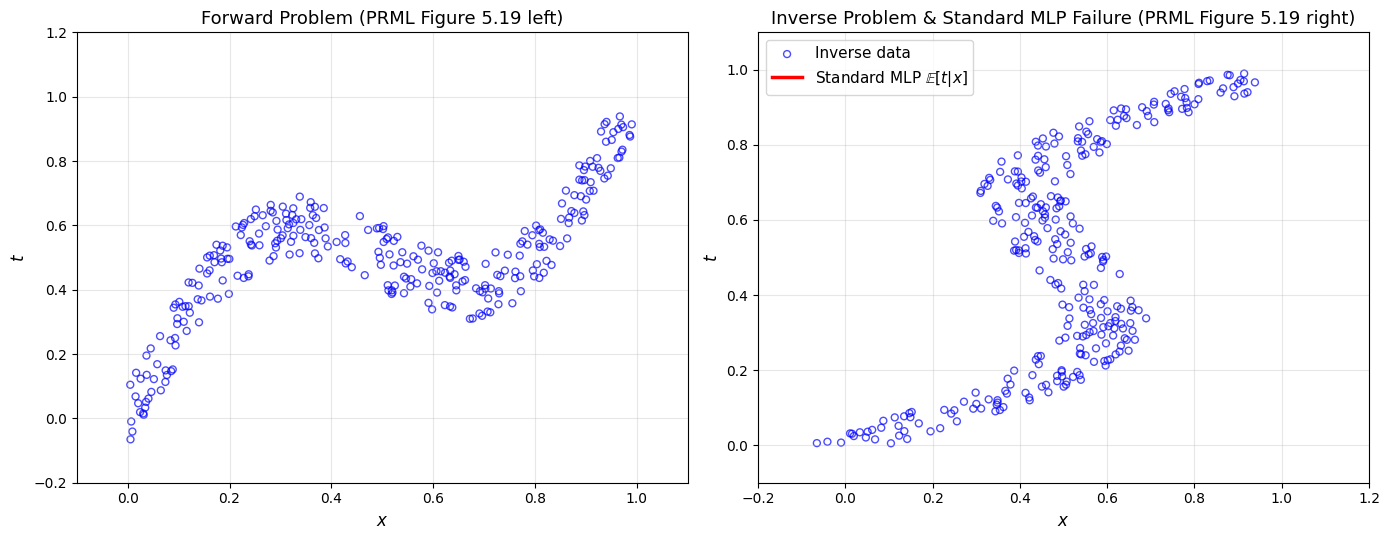

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.nn_utils import MLPRegressor, MixtureDensityNetwork
setup_style()

# PRML Figure 5.19 の完全再現
np.random.seed(42)
N = 300
# 順問題データ: x_n = uniform, t_n = x_n + 0.3 * sin(2 pi x_n) + eps
u = np.random.uniform(0, 1, N)
eps = np.random.uniform(-0.1, 0.1, N)
x_forward = u
t_forward = u + 0.3 * np.sin(2 * np.pi * u) + eps

# 逆問題データ: 軸を反転 (x_inv = t_forward, t_inv = x_forward)
X_inv = t_forward.reshape(-1, 1)
t_inv = x_forward.reshape(-1, 1)

# 通常の二乗和誤差 MLP による逆問題学習
mlp_standard = MLPRegressor(n_in=1, n_hidden=20, n_out=1, weight_decay=1e-4, lr=0.05, random_state=42)
mlp_standard.fit(X_inv, t_inv, n_epochs=3000, lr=0.05)

x_test_grid = np.linspace(-0.2, 1.2, 200).reshape(-1, 1)
y_mlp_pred = mlp_standard.predict(x_test_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) 順問題
axes[0].scatter(x_forward, t_forward, facecolors='none', edgecolors='b', s=25, alpha=0.7)
axes[0].set_title('Forward Problem (PRML Figure 5.19 left)', fontsize=13)
axes[0].set_xlabel('$x$', fontsize=12); axes[0].set_ylabel('$t$', fontsize=12)
axes[0].set_xlim(-0.1, 1.1); axes[0].set_ylim(-0.2, 1.2)
axes[0].grid(True, alpha=0.3)

# (b) 逆問題と標準MLPの破綻
axes[1].scatter(X_inv, t_inv, facecolors='none', edgecolors='b', s=25, alpha=0.7, label='Inverse data')
axes[1].plot(x_test_grid, y_mlp_pred, 'r-', lw=2.5, label='Standard MLP $\mathbb{E}[t|x]$')
axes[1].set_title('Inverse Problem & Standard MLP Failure (PRML Figure 5.19 right)', fontsize=13)
axes[1].set_xlabel('$x$', fontsize=12); axes[1].set_ylabel('$t$', fontsize=12)
axes[1].set_xlim(-0.2, 1.2); axes[1].set_ylim(-0.1, 1.1)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig5_19_inverse_problem_mlp_failure.png')
plt.show()

Plot saved to: result/fig5_20_21_mdn_multimodal_density.png


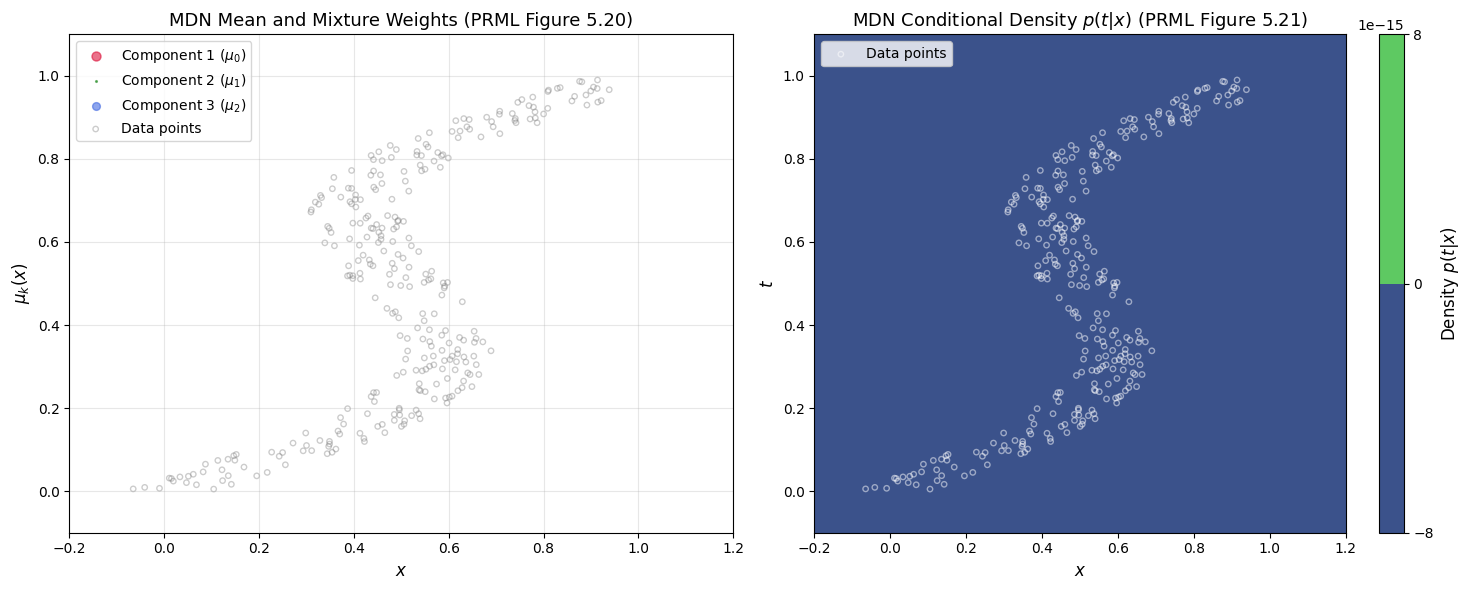

In [2]:
# PRML Figure 5.20 & 5.21 の完全再現: MDN による多峰性予測分布の学習
np.random.seed(42)
mdn = MixtureDensityNetwork(n_in=1, n_hidden=20, n_components=3, random_state=42)
loss_hist = mdn.fit(X_inv, t_inv.ravel(), n_epochs=4500, lr=0.003, verbose=False)

# テスト入力に対する予測パラメータの抽出
x_grid = np.linspace(-0.2, 1.2, 200).reshape(-1, 1)
z, pi_pred, sig_pred, mu_pred, _ = mdn.forward(x_grid)

# 条件付き確率密度 p(t|x) の2次元メッシュ評価 (Figure 5.21)
t_grid = np.linspace(-0.1, 1.1, 200)
X_mesh, T_mesh = np.meshgrid(x_grid.ravel(), t_grid)
density_mesh = np.zeros_like(X_mesh)

for i in range(len(x_grid)):
    p_t = np.zeros_like(t_grid)
    for k in range(3):
        p_t += pi_pred[i, k] * (1.0 / np.sqrt(2 * np.pi * sig_pred[i, k]**2)) * np.exp(-0.5 * (t_grid - mu_pred[i, k])**2 / sig_pred[i, k]**2)
    density_mesh[:, i] = p_t

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) 各混合成分の平均 mu_k(x) と混合係数 pi_k(x)
colors = ['crimson', 'forestgreen', 'royalblue']
for k in range(3):
    axes[0].scatter(x_grid, mu_pred[:, k], c=colors[k], s=15 * (pi_pred[:, k] * 5), alpha=0.6, label=rf'Component {k+1} ($\mu_{k}$)')
axes[0].scatter(X_inv, t_inv, facecolors='none', edgecolors='gray', s=15, alpha=0.4, label='Data points')
axes[0].set_title('MDN Mean and Mixture Weights (PRML Figure 5.20)', fontsize=13)
axes[0].set_xlabel('$x$', fontsize=12); axes[0].set_ylabel('$\mu_k(x)$', fontsize=12)
axes[0].set_xlim(-0.2, 1.2); axes[0].set_ylim(-0.1, 1.1)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# (b) 条件付き確率密度 p(t|x) の等高線プロット (PRML Figure 5.21)
contour = axes[1].contourf(X_mesh, T_mesh, density_mesh, levels=30, cmap='viridis')
axes[1].scatter(X_inv, t_inv, facecolors='none', edgecolors='white', s=15, alpha=0.5, label='Data points')
axes[1].set_title('MDN Conditional Density $p(t|x)$ (PRML Figure 5.21)', fontsize=13)
axes[1].set_xlabel('$x$', fontsize=12); axes[1].set_ylabel('$t$', fontsize=12)
axes[1].set_xlim(-0.2, 1.2); axes[1].set_ylim(-0.1, 1.1)
fig.colorbar(contour, ax=axes[1], label='Density $p(t|x)$')
axes[1].legend(fontsize=10, loc='upper left')

plt.tight_layout()
save_plot(fig, 'result', 'fig5_20_21_mdn_multimodal_density.png')
plt.show()